# Dark Photon Kinetic Mixing Limits

This notebook compiles and visualizes constraints on epsilon as a function of dark photon mass from multiple analysis methods:

- **CMB constraints**: Existing limits from FIRAS and Planck observations
- **Halo model**: Constraints from halo-based galaxy clustering cross-correlations
- **21cmFAST simulations**: Limits from high-redshift IGM during Epoch of Reionization
- **Analytic IGM model**: Constraints from low-redshift intergalactic medium
- **Global 21cm signal**: Limits from spatially-averaged 21cm brightness temperature

The notebook produces forecast limit plots comparing auto-correlation and cross-correlation sensitivities across different observational environments.

In [2]:
import os, sys
import pickle

import matplotlib_inline
sys.path.append("../")

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from matplotlib import gridspec
from matplotlib import ticker
from matplotlib.lines import Line2D

from tqdm import tqdm

from scipy.interpolate import interp1d
import numpy as np

matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

%matplotlib inline
%load_ext autoreload
%autoreload 2
# Load plot settings
import healpy as hp
from plot_params import params
pylab.rcParams.update(params)

cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

## Load CMB Constraints

Load existing constraints from CMB observations:
- FIRAS data providing  limits from spectral distortions
- Planck cross-correlation with unWISE galaxies 

In [3]:
# load previous limits
m_A_FIRAS, lim_FIRAS = np.transpose(np.loadtxt("data/fiducial_DP_FIRAS_one_plus_delta_1e2.csv", skiprows=2, delimiter=','))
planck_lims = np.genfromtxt("data/Planck_unwise.csv", delimiter=',').T


In [ ]:
# Load halo model constraints (Environment A)
model_A = np.load("data/halo_lims.npy")
model_A_mA = np.load("data/halo_mA.npy")
model_A[:, 1:] = np.where(model_A[:, 1:] <= 2e-9, 1000, model_A[:, 1:])  # Filter where there are no limits

model_A_nfw_mA = np.load("/usr3/graduate/ebaker/dark_photon_constraints/notebooks_for_paper/data/halo_mA_nfw.npy")
model_A_nfw = np.load("/usr3/graduate/ebaker/dark_photon_constraints/notebooks_for_paper/data/halo_lims_nfw.npy")
model_A_nfw[:, 1:] = np.where(model_A_nfw[:, 1:] <= 2e-9, 1000, model_A_nfw[:, 1:])  # Filter where there are no limits


model_A_shock = np.load("/usr3/graduate/ebaker/dark_photon_constraints/notebooks_for_paper/data/halo_lims_shock.npy")
model_A_shock[:, 1:] = np.where(model_A_shock[:, 1:] <= 2e-9, 1000, model_A_shock[:, 1:])  # Filter where there are no limits
model_A_K23 = np.load("/usr3/graduate/ebaker/dark_photon_constraints/notebooks_for_paper/data/halo_lims_K23.npy")
model_A_K23[:, 1:] = np.where(model_A_K23[:, 1:] <= 2e-9, 1000, model_A_K23[:, 1:])  # Filter where there are no limits

model_A_radio_bias = np.load("/usr3/graduate/ebaker/dark_photon_constraints/notebooks_for_paper/data/halo_lims_K22_unwise.npy")
model_A_radio_bias[:, 1:] = np.where(model_A_radio_bias[:, 1:] <= 5e-10, 1000, model_A_radio_bias[:, 1:])  # Filter where there are no limits
# Load 21cmFAST constraints (Environment B - high-z EoR)
model_B = np.load("data/21cmfast_lims.npy")
model_B_mA = np.load("data/21cmfast_mA.npy")
model_B = np.where(model_B == 0, 1000, model_B)  # Replace zeros with placeholder
model_B[-3:, ...] = 1000  # Exclude last few problematic mass bins

# Load analytic IGM constraints (Environment B+C - dominated by conversions in low-z IGM)
model_BC = np.load("data/environment_BC_limits.npy")
model_BC_mA = np.load("data/21cmfast_analytic_mA.npy")
model_BC = np.where(model_BC == 0, 1000, model_BC)

# Load global 21cm signal constraints
global_signal_lims = np.load("data/21cm_global_lognorm_lims.npy")

In [5]:
def plot_band(masses, results, auto=True, label=None, ls=None, color=None):
    axis = 0 if auto else 1
    ls = "-" if not auto else ":"
    # plt.scatter(np.repeat(masses, 50), results[:, :, axis].flatten(), s=5, color=color, alpha=0.5);
    plt.plot(masses, np.nanmedian(results[:, :, axis], axis=1), color=color, ls=ls, label=label);
    plt.fill_between(masses, np.percentile(results, 5, axis=1)[:, axis], np.percentile(results, 95, axis=1)[:, axis], alpha=0.2, color=color)
    return None

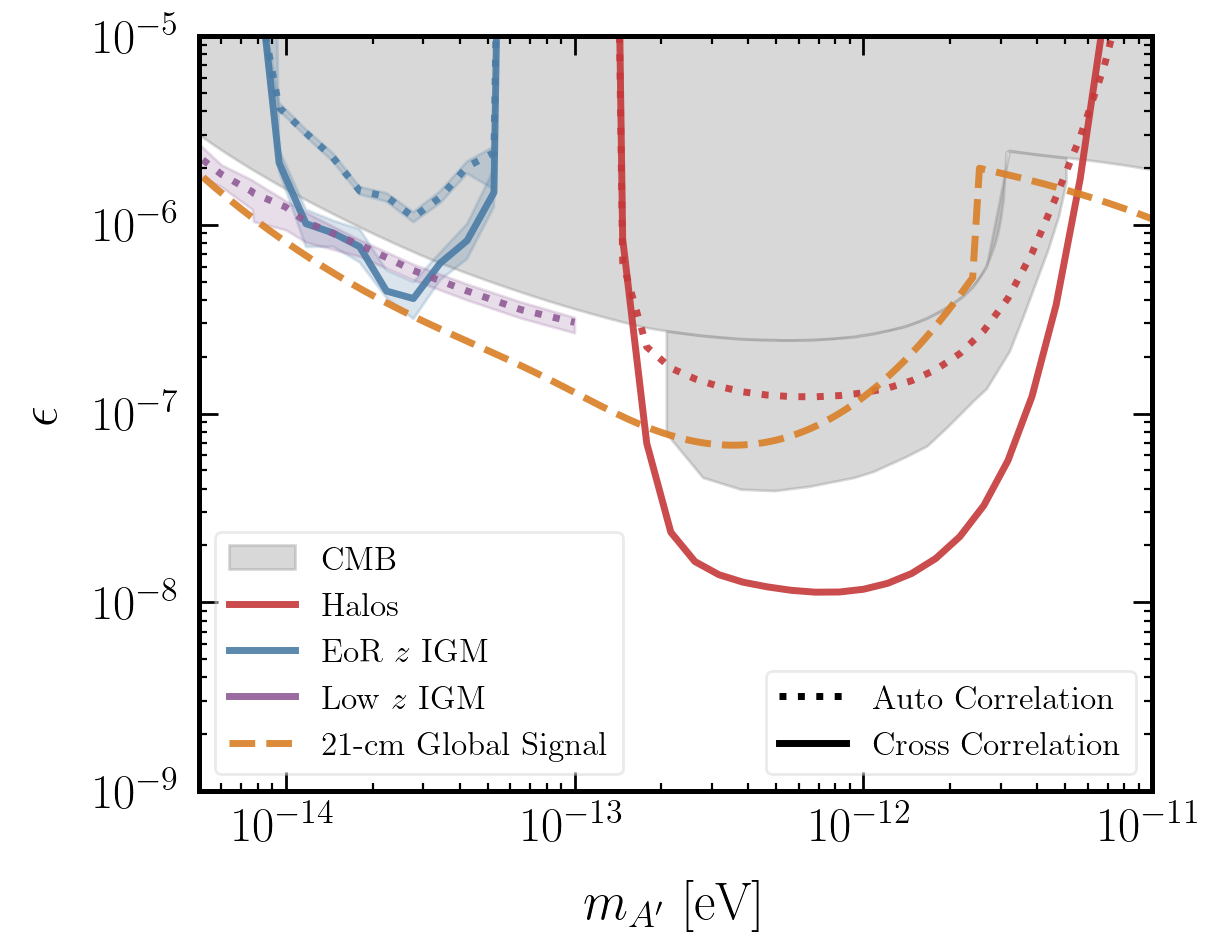

In [6]:
#plots the same thing by different labels 
plt.fill_between(m_A_FIRAS, lim_FIRAS, 1e-3, color="grey", alpha=0.3, label="CMB")
plt.fill_between(planck_lims[0,:],
                    planck_lims[1,:], 
                    interp1d(m_A_FIRAS, lim_FIRAS)(planck_lims[0,:]), 
                    where=planck_lims[1,:]<= interp1d(m_A_FIRAS, lim_FIRAS)(planck_lims[0,:]), 
                    color="grey", 
                    alpha=0.3,)

plt.plot(model_A[:,0], model_A[:, 1], ls=":", color=cols_default[0])
plt.plot(model_A[:,0], model_A[:, 2], label="Halos", color=cols_default[0])

plot_band(model_B_mA, model_B, auto=True,  color=cols_default[1],)
plot_band(model_B_mA, model_B, auto=False, color=cols_default[1], label=r"EoR $z$ IGM")

plot_band(model_BC_mA, model_BC, auto=True,color=cols_default[3],)
plt.plot([0,1],[0,1],linestyle='-', label=r"Low $z$ IGM", color=cols_default[3]) # for the legend


plt.plot(global_signal_lims[:,0], global_signal_lims[:, 1], label="21-cm Global Signal", linestyle="--", color=cols_default[4])


# just for the legend
auto_line = Line2D([0,1],[0,1],linestyle=':', color='k')
cross_line = Line2D([0,1],[0,1],linestyle='-', color='k')
legend2 = plt.legend([auto_line, cross_line], ['Auto Correlation', 'Cross Correlation'], fontsize=12, loc="lower right", frameon=True)
plt.gca().add_artist(legend2)
legend1 = plt.legend(fontsize=12, loc="lower left", frameon=True) # loc='center left', bbox_to_anchor=(1, 0.5))


plt.ylim(1e-9, 1e-5)
plt.xlim(0.5e-14, 1e-11)

plt.xlabel(r"$m_{A'}$ [eV]")
plt.ylabel(r"$\epsilon$")

plt.xscale("log")
plt.yscale("log")
# plt.title("SKA")

plt.savefig("plots/prl_forecast_limits.pdf", bbox_inches='tight',)

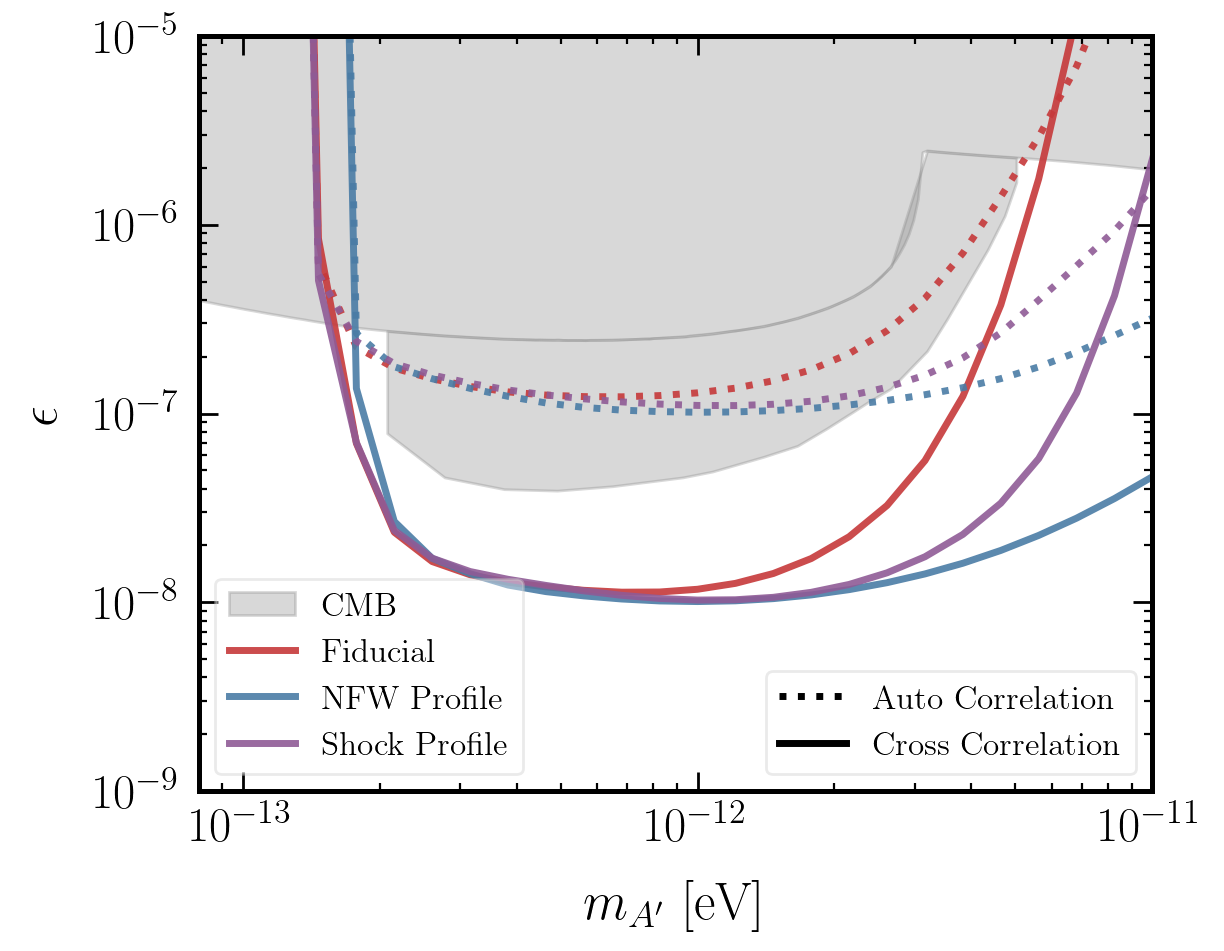

In [16]:
#plot CMB Limits
plt.fill_between(m_A_FIRAS, lim_FIRAS, 1e-3, color="grey", alpha=0.3, label="CMB")

# Add Planck improvement where it's stronger than FIRAS
plt.fill_between(planck_lims[0, :],
                 planck_lims[1, :], 
                 interp1d(m_A_FIRAS, lim_FIRAS)(planck_lims[0, :]), 
                 where=planck_lims[1, :] <= interp1d(m_A_FIRAS, lim_FIRAS)(planck_lims[0, :]), 
                 color="grey", 
                 alpha=0.3)

# Plot halo model constraints (Environment A)
plt.plot(model_A[:, 0], model_A[:, 1], ls=":", color=cols_default[0])  # Auto
plt.plot(model_A[:, 0], model_A[:, 2], label="Fiducial", color=cols_default[0])  # Cross

plt.plot(model_A_nfw_mA, model_A_nfw[:, 1], ls=":", color=cols_default[1])  # Auto
plt.plot(model_A_nfw_mA, model_A_nfw[:, 2], label="NFW Profile", color=cols_default[1])  # Cross
plt.plot(model_A_shock[:, 0], model_A_shock[:, 1], ls=":", color=cols_default[3])  # Auto
plt.plot(model_A_shock[:, 0], model_A_shock[:, 2], label="Shock Profile", color=cols_default[3])  # Cross
# plt.plot(model_A_K23[:, 0], model_A_K23[:, 1], ls=":", color=cols_default[6])  # Auto
# plt.plot(model_A_K23[:, 0], model_A_K23[:, 2], label="K23 HOD", color=cols_default[6])  # Cross
# Plot 21cmFAST constraints with uncertainty bands (Environment B)
# Create custom legend for line styles
auto_line = Line2D([0, 1], [0, 1], linestyle=':', color='k')
cross_line = Line2D([0, 1], [0, 1], linestyle='-', color='k')
legend2 = plt.legend([auto_line, cross_line], ['Auto Correlation', 'Cross Correlation'], 
                     fontsize=12, loc="lower right", frameon=True)
plt.gca().add_artist(legend2)
legend1 = plt.legend(fontsize=12, loc="lower left", frameon=True)

plt.ylim(1e-9, 1e-5)
plt.xlim(8e-14, 1e-11)

plt.xlabel(r"$m_{A'}$ [eV]")
plt.ylabel(r"$\epsilon$")

plt.xscale("log")
plt.yscale("log")
# 
plt.savefig("plots/prd_forecast_limits_gas_profile.pdf", bbox_inches='tight')

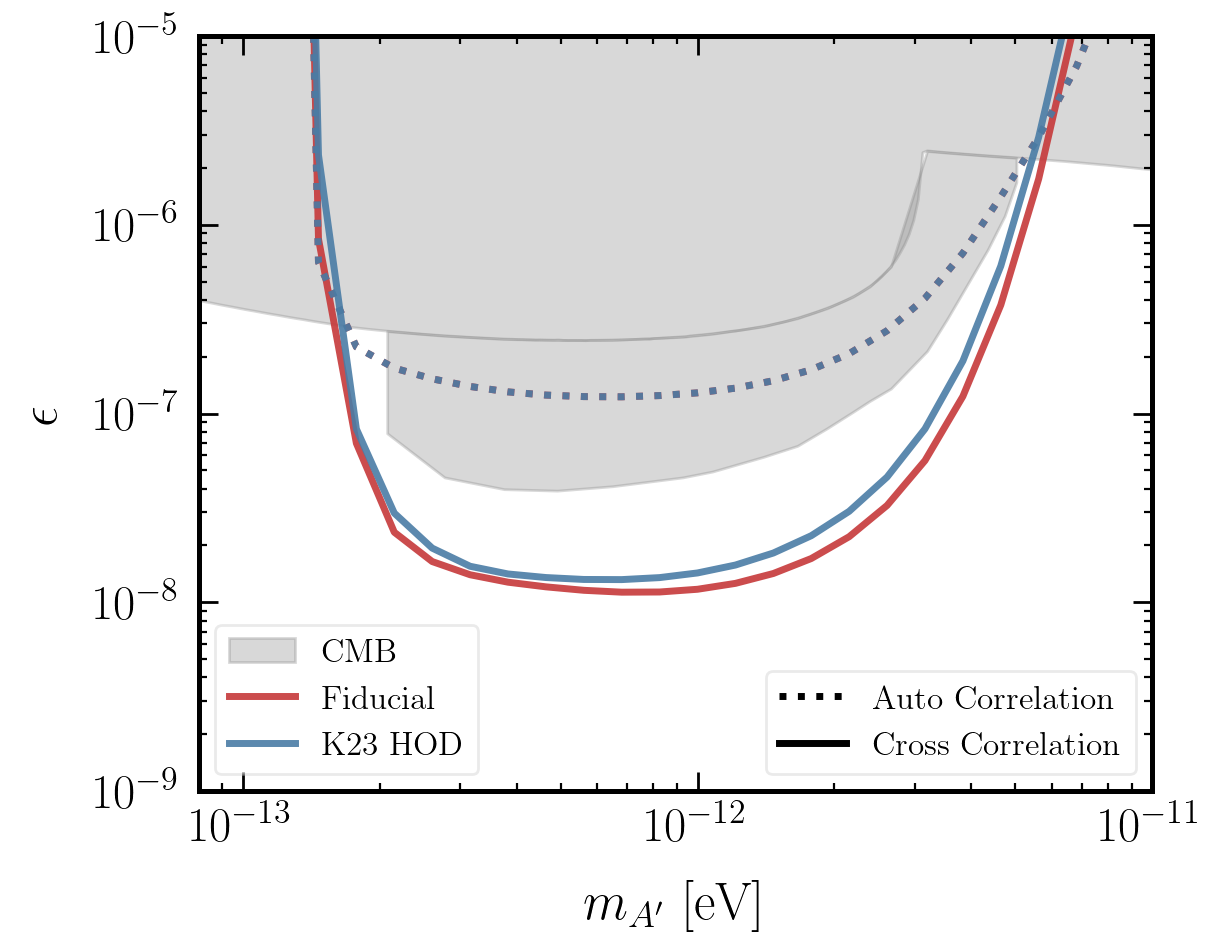

In [17]:
#plot CMB Limits
plt.fill_between(m_A_FIRAS, lim_FIRAS, 1e-3, color="grey", alpha=0.3, label="CMB")

# Add Planck improvement where it's stronger than FIRAS
plt.fill_between(planck_lims[0, :],
                 planck_lims[1, :], 
                 interp1d(m_A_FIRAS, lim_FIRAS)(planck_lims[0, :]), 
                 where=planck_lims[1, :] <= interp1d(m_A_FIRAS, lim_FIRAS)(planck_lims[0, :]), 
                 color="grey", 
                 alpha=0.3)

# Plot halo model constraints (Environment A)
plt.plot(model_A[:, 0], model_A[:, 1], ls=":", color=cols_default[0])  # Auto
plt.plot(model_A[:, 0], model_A[:, 2], label="Fiducial", color=cols_default[0])  # Cross

# plt.plot(model_A_nfw_mA, model_A_nfw[:, 1], ls=":", color=cols_default[1])  # Auto
# plt.plot(model_A_nfw_mA, model_A_nfw[:, 2], label="NFW Profile", color=cols_default[1])  # Cross
# plt.plot(model_A_shock[:, 0], model_A_shock[:, 1], ls=":", color=cols_default[3])  # Auto
# plt.plot(model_A_shock[:, 0], model_A_shock[:, 2], label="Shock Profile", color=cols_default[3])  # Cross
plt.plot(model_A_K23[:, 0], model_A_K23[:, 1], ls=":", color=cols_default[1])  # Auto
plt.plot(model_A_K23[:, 0], model_A_K23[:, 2], label="K23 HOD", color=cols_default[1])  # Cross
# Plot 21cmFAST constraints with uncertainty bands (Environment B)
# Create custom legend for line styles
auto_line = Line2D([0, 1], [0, 1], linestyle=':', color='k')
cross_line = Line2D([0, 1], [0, 1], linestyle='-', color='k')
legend2 = plt.legend([auto_line, cross_line], ['Auto Correlation', 'Cross Correlation'], 
                     fontsize=12, loc="lower right", frameon=True)
plt.gca().add_artist(legend2)
legend1 = plt.legend(fontsize=12, loc="lower left", frameon=True)

plt.ylim(1e-9, 1e-5)
plt.xlim(8e-14, 1e-11)

plt.xlabel(r"$m_{A'}$ [eV]")
plt.ylabel(r"$\epsilon$")

plt.xscale("log")
plt.yscale("log")
# 
plt.savefig("plots/prd_forecast_limits_hod.pdf", bbox_inches='tight')